### Nome: Thiago Domingos Venturim Ribeiro dos Santos

# AM — Aula prática 01: classificação supervisionada

**Disciplina:** Aprendizado de Máquina · **Ferramentas:** Python, `scikit-learn`, `pandas`, `matplotlib`/`seaborn`

## Objetivos de aprendizagem (formativos)

Este laboratório tem caráter **formativo**: não há **uma única resposta correta** para todos os números e gráficos. O valor está em **experimentar**, **registrar** o que você fez (código, figuras, comentários breves) e **relacionar** com a teoria da disciplina.

- Explorar dados com **EDA** e raciocinar sobre **pré-processamento**.
- Montar **pipelines** (`StandardScaler` + classificador) e treinar **árvore de decisão**, **SVM** e **Naive Bayes** (Gaussiano).
- **Explorar hiperparâmetros** e relacionar com *overfitting*, generalização e intuição de cada modelo.
- Usar **validação cruzada** com `Pipeline` e entender **vazamento de informação** (*data leakage*).
- Opcionalmente aprofundar com **ROC**, **métricas** além da acurácia e **importância de variáveis**.

**Trabalho em dupla** é incentivado para discutir resultados; cada pessoa deve **manter seu próprio notebook** com o código que executou e suas observações.

## Contexto e uso responsável dos dados

O conjunto **Breast Cancer Wisconsin** (`load_breast_cancer`) é **clássico no ensino de ML**: atributos numéricos, rótulo binário (maligno vs benigno). Ele serve para **aprender métodos e pipelines**, não para substituir **diagnóstico clínico**. Há limitações de **época**, **população** e **contexto de coleta**; não extrapole conclusões para aplicações reais sem estudo específico.

## Dataset (técnico)

**Breast Cancer Wisconsin** — classificação binária, apenas atributos numéricos (`sklearn.datasets.load_breast_cancer`).

## Como usar este notebook

As **partes 1–4** são o **núcleo** da experimentação; a **parte 5** é **exploração livre** (sala ou casa). As células de **código vazio** são o **seu espaço**: implemente, teste e refine o **seu** pipeline. Há **uma** célula de **demonstração** logo após os imports — execute como referência; o trabalho formativo está em **reproduzir, variar e interpretar** nas demais células.


## 0. Configuração do ambiente

Execute a célula abaixo. Se faltar algum pacote: `pip install scikit-learn pandas matplotlib seaborn`.


In [1]:
# Imports — amplie com outros módulos do sklearn conforme os enunciados
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_fscore_support,
)

# Em exploração, os avisos do sklearn podem ser pedagógicos (convergência etc.).
# Descomente a linha seguinte se quiser suprimir avisos de usuário.
# warnings.filterwarnings("ignore", category=UserWarning)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
rng_seed = 42


### Conexão rápida com a teoria

| Abordagem | Lembrete |
|-----------|----------|
| **Árvore de decisão** | Cortes nos eixos das features; a **escala** afeta **quais** partições são escolhidas primeiro (e portanto o modelo), de forma diferente de SVM. |
| **SVM (kernel RBF)** | Fronteira não linear; **escalonamento** costuma ser essencial. `C` e `gamma` regulam **margem** vs **ajuste** aos dados. |
| **Naive Bayes Gaussiano** | Hipótese de **independência condicional** entre features; bom **baseline** probabilístico. |

Relacione o que você observar com **viés**, **variância** e **capacidade** do modelo vistos na aula teórica.


In [2]:
# Demonstração — pipeline mínimo (referência). Depois construa o seu nas atividades.
# Objetivo: mostrar fit → predict → acurácia num fluxo único. Não substitui as Partes 1–4.

data_demo = load_breast_cancer()
X_d, y_d = data_demo.data, data_demo.target
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.25, random_state=rng_seed, stratify=y_d
)
scaler_d = StandardScaler()
X_train_sd = scaler_d.fit_transform(X_train_d)
X_test_sd = scaler_d.transform(X_test_d)

clf_demo = SVC(kernel="rbf", random_state=rng_seed)
clf_demo.fit(X_train_sd, y_train_d)
acc_demo = accuracy_score(y_test_d, clf_demo.predict(X_test_sd))
print("Demo: acurácia (SVM RBF + dados escalonados):", round(acc_demo, 4))


Demo: acurácia (SVM RBF + dados escalonados): 0.979


---

## Parte 1 — Carga dos dados e EDA

Use as **células de código vazias** desta parte para **sua** exploração; acrescente células se precisar de mais espaço.

### Atividade 1.1 — Primeiro contato
1. Carregue o dataset com `load_breast_cancer()` e monte um `pandas.DataFrame` com as features e a coluna alvo (rótulo).
2. Informe: número de linhas, número de features, nomes das classes (`target_names` do objeto retornado pelo `load_breast_cancer`).
3. Verifique se há valores ausentes (`NaN`) nas colunas (por exemplo com `DataFrame.isna` somado por coluna ou no total).
4. Conte quantos exemplos há em cada classe e comente se a distribuição é aproximadamente **balanceada** ou não.

> **Enunciado:** você pode usar `sklearn.datasets.load_breast_cancer`, atributos `.data`, `.target`, `.feature_names`, `.target_names`, e `pandas`.


In [3]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

X = pd.DataFrame(X)
y = pd.DataFrame(y)
print(f"Numero de linhas e colunas de X : {X.shape} e Y : {y.shape}\nTarget Name: {y.columns.values}")
X.isna()


Numero de linhas e colunas de X : (569, 30) e Y : (569, 1)
Target Name: ['target']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:

print(y.value_counts())

target
1         357
0         212
Name: count, dtype: int64


### Atividade 1.2 — Escalas e relações entre variáveis
1. Use estatísticas descritivas (`describe()` ou equivalente) e aponte **duas** features cuja **escala** (ordem de grandeza) seja claramente diferente.
2. Produza uma visualização da **matriz de correlação** entre as features (por exemplo com `seaborn.heatmap` ou `pandas.DataFrame.corr`). Comente brevemente se há grupos de variáveis muito correlacionadas.

> **Enunciado:** métodos úteis incluem `DataFrame.describe`, `DataFrame.corr`, `seaborn.heatmap`.


In [5]:
X.describe()



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
X[["worst area","mean radius"]].corr()

,worst area,mean radius
worst area,1.000000,0.941082
mean radius,0.941082,1.000000


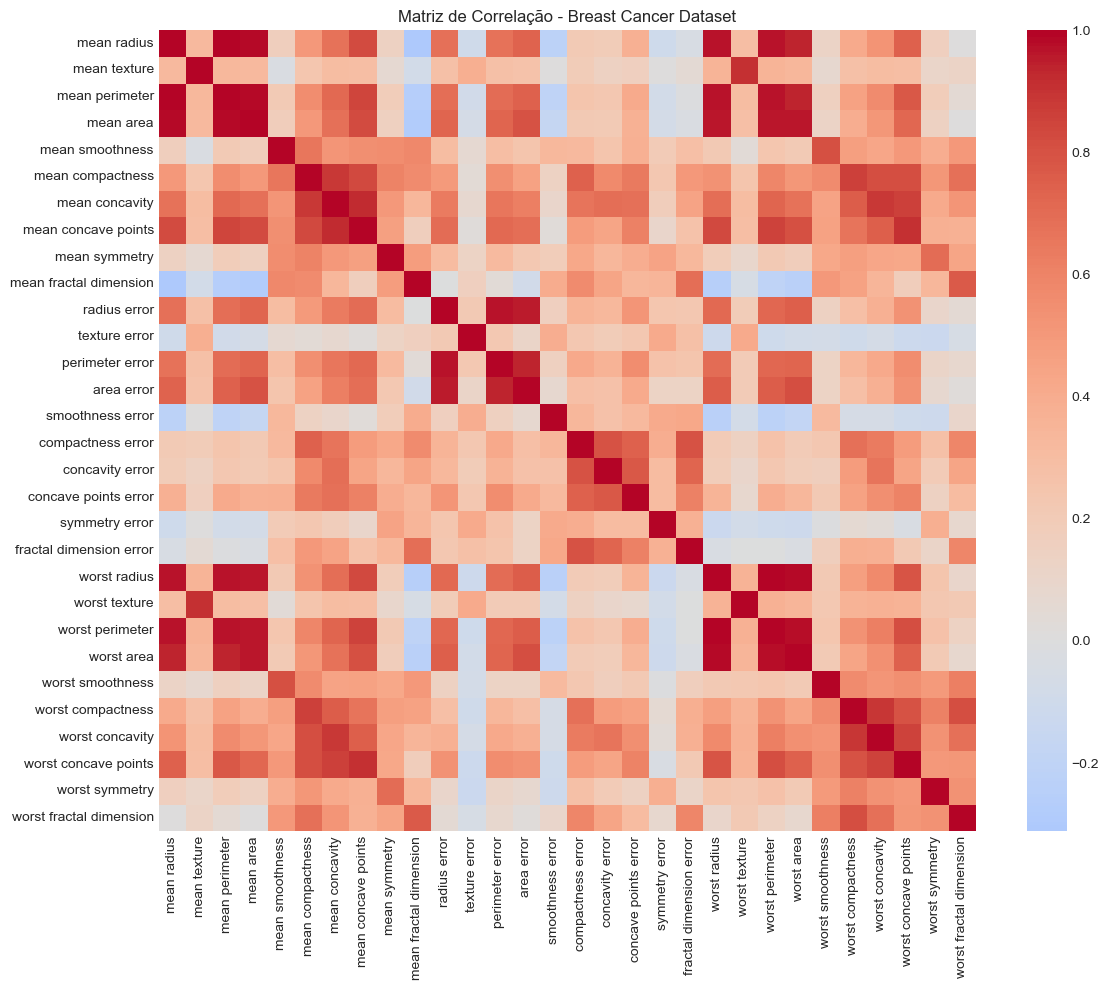

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), 
            annot=False,     
            cmap='coolwarm', 
            fmt=".2f",       
            center=0)        

# 5. Ajustes finais de título e layout
plt.title('Matriz de Correlação - Breast Cancer Dataset')
plt.tight_layout()

# Exibir o gráfico
plt.show()


Resposta: Sim, há grupos de variáveis fortemente correlacionadas, o que indica redundância de informação no dataset. Os principais são:

Grupo de Geometria/Tamanho: As variáveis Radius (raio), Perimeter (perímetro) e Area (área) formam o grupo mais forte. Isso ocorre porque são dependentes matematicamente: se o raio de uma célula aumenta, sua área e perímetro obrigatoriamente aumentam também.

Grupo de Irregularidade: Há uma correlação alta entre Compactness (compacidade), Concavity (concavidade) e Concave Points (pontos côncavos). Isso indica que células com contornos mais complexos tendem a apresentar todas essas características simultaneamente.

Relação entre Médias e Piores Casos: Existe uma forte correlação entre as medidas "mean" (média) e "worst" (pior/maior valor) para a mesma característica (ex: mean radius e worst radius).

### Leitura rápida (conceito)

Na cópia do dataset distribuída pelo `scikit-learn`, costuma **não** haver valores faltantes — ainda assim, em projetos reais a checagem é obrigatória. Para imputação, veja `sklearn.impute.SimpleImputer` na documentação oficial.

---

## Parte 2 — Divisão dos dados, escalonamento e baseline

Aqui você monta o **pipeline** de pré-processamento e os três classificadores — use quantas células de código forem necessárias (incluindo células novas).

### Atividade 2.1 — Treino / teste e `StandardScaler`
1. Defina `X` (matriz de features) e `y` (vetor de rótulos).
2. Divida em treino e teste com `sklearn.model_selection.train_test_split`, com `test_size=0.25`, `random_state=42` e `stratify=y`.
3. Ajuste um `StandardScaler` **apenas** com o conjunto de treino (`fit` no treino; `transform` em treino e teste). Explique em uma frase por que não se deve usar o conjunto de teste para calcular média e desvio usados na padronização.

> **Enunciado:** `sklearn.preprocessing.StandardScaler`, `train_test_split`.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.25)

scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"X: Train {X_train.shape} Test {X_test.shape}\nY: Train {y_train.shape} Test {y_test.shape} ")

X: Train (426, 30) Test (143, 30)
Y: Train (426, 1) Test (143, 1) 


### Atividade 2.2 — Três classificadores (primeira versão)

Treine **separadamente** (no treino escalonado, avalie no teste escalonado):

| Modelo | Classe |
|--------|--------|
| Árvore de decisão | `sklearn.tree.DecisionTreeClassifier` |
| SVM | `sklearn.svm.SVC` |
| Naive Bayes | `sklearn.naive_bayes.GaussianNB` |

Para cada um: instancie o estimador, chame `fit`, obtenha predições no teste, calcule **acurácia** e exiba `sklearn.metrics.classification_report`. Use `random_state=42` na árvore e no SVM onde aplicável; para o kernel do SVM, use por exemplo RBF (`kernel="rbf"`).

Em **markdown** (célula de reflexão da Parte 2.2), responda: a **árvore** depende da escala das features da mesma forma que o SVM? Por quê?

> **Enunciado:** `fit`, `predict`, `accuracy_score`, `classification_report`.


In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)
y_pred_tree = tree.predict(X_test)
print(accuracy_score(y_test,y_pred_tree ))
print(classification_report(y_test,y_pred_tree ))

0.9440559440559441
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        54
           1       0.97      0.94      0.95        89

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [ ]:
svc = SVC()
svc.fit(X_train,y_train)
y_pred_svc = svc.predict(X_test)
print(accuracy_score(y_test,y_pred_svc ))
print(classification_report(y_test,y_pred_svc ))

0.951048951048951
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        54
           1       0.94      0.99      0.96        89

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
nv = GaussianNB()
nv.fit(X_train,y_train)
y_pred_nv = svc.predict(X_test)
print(accuracy_score(y_test,y_pred_nv))
print(classification_report(y_test,y_pred_nv ))

0.951048951048951
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        54
           1       0.94      0.99      0.96        89

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### Reflexão em texto — Parte 2.2 (árvore vs escala)

Resposta: Não, A árvore de decisão não depende de escalas das features da mesma forma que a snv, pois enquanto a snv é altamente senvicel à escalas exigindo um pre tratamento, padronização e normalização as arvores de decisao são mais robustas a diferemtes escalas.



### Atividade 2.3 — Matriz de confusão

Escolha **um** dos três modelos treinados acima e exiba a **matriz de confusão** no conjunto de teste. Você pode usar `sklearn.metrics.ConfusionMatrixDisplay.from_predictions` ou combinar `confusion_matrix` com um gráfico.

Explique o significado de **falso positivo** e **falso negativo** neste problema (maligno vs benigno): qual tipo de erro costuma ser mais grave em um cenário de triagem médica? *(Reflexão em markdown na célula dedicada abaixo.)*

> **Enunciado:** `ConfusionMatrixDisplay`, `confusion_matrix`.


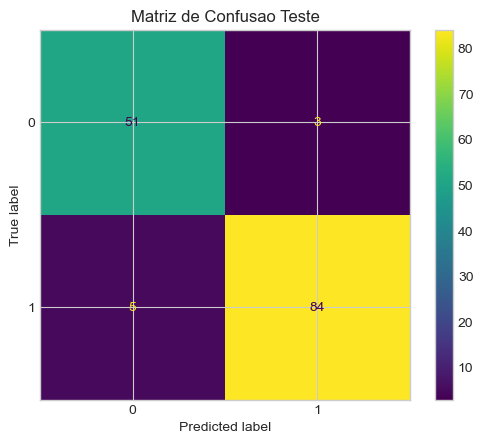

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Matriz de Confusao Teste")
plt.show()

#### Reflexão em texto — Parte 2.3 (interpretação)


Resposta: O **falso positivo** são variaveis que o modelo considerou como postivas ou seja maligno mas eram benigno, **falso negativo** neste problema são variaveis que o modelo considerou como  negativa ou seja benigno mas eram maligno.

Em termos medicos os dois lados tem um grande problema, pois uma pessoa classifica com falso positivo recebe um susto desnecessário, passando por ansiedade elevada e, frequentemente, submetendo-se a exames adicionais invasivos, como biópsias, que trazem riscos físicos e custos. Entretanto se for classicado um falso negativo a pessoa não fara o tratamento e podera chegar a morte ou tratamento tardio, ou seja no pior cenario um falso negativo é o pior.

---

## Parte 3 — Hiperparâmetros (trilha principal de experimentação)

Nesta parte você **explora** o efeito de hiperparâmetros: varie valores, registre resultados (tabelas ou gráficos) e **conecte** com capacidade do modelo e *overfitting*. O objetivo é **ver o que muda**, não acertar um único número.

### Atividade 3.1 — Árvore de decisão
Varie de forma explícita **pelo menos dois** hiperparâmetros da árvore (exemplos: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_leaf_nodes`). Para cada configuração (ou para um conjunto reduzido de combinações), avalie o desempenho usando **validação cruzada** no conjunto de treino (por exemplo `cross_val_score` com `Pipeline` contendo apenas o classificador na árvore, ou validação estratificada). **Não use o conjunto de teste** para escolher hiperparâmetros.

Apresente uma **tabela ou gráfico** (por exemplo: acurácia média vs `max_depth`) e indique qual configuração você escolheria e por quê.

> **Enunciado:** `DecisionTreeClassifier`, `sklearn.model_selection.cross_val_score`, `StratifiedKFold`; opcionalmente `sklearn.model_selection.validation_curve` para uma grade unidimensional de valores.


In [ ]:
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

configs = [
    {'max_depth': 2, 'min_samples_leaf': 1},
    {'max_depth': 5, 'min_samples_leaf': 1},
    {'max_depth': 10, 'min_samples_leaf': 1},
    {'max_depth': 5, 'min_samples_leaf': 10},
    {'max_depth': None, 'min_samples_leaf': 1} 
]

resultados = []

for conf in configs:
    tree = DecisionTreeClassifier(random_state=42, **conf)
    scores = cross_val_score(tree, X_train, y_train.values.ravel(), cv=kf)
    resultados.append({
        'Max Depth': conf['max_depth'],
        'Min Samples Leaf': conf['min_samples_leaf'],
        'Acurácia Média': np.mean(scores),
        'Desvio Padrão': np.std(scores)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.sort_values(by='Acurácia Média', ascending=False))

   Max Depth  Min Samples Leaf  Acurácia Média  Desvio Padrão
1        5.0                 1        0.931929       0.022798
2       10.0                 1        0.920164       0.018908
4        NaN                 1        0.920164       0.018908
3        5.0                10        0.910780       0.017689
0        2.0                 1        0.906074       0.019804


#### Reflexão em texto — Parte 3.1 (conclusão da árvore)

Resposta: Observou-se que árvores muito profundas (max_depth = 10 ou sem limite) apresentaram leve queda na acurácia, indicando possível overfitting. Por outro lado, árvores muito rasas (max_depth = 2) tiveram desempenho inferior, caracterizando underfitting.Em relação ao parâmetro min_samples_leaf, valores maiores (como 10) reduziram a acurácia, sugerindo simplificação excessiva do modelo.

A melhor configuração encontrada foi max_depth = 5 e min_samples_leaf = 1, com acurácia média de aproximadamente 0.932. Essa configuração apresenta um bom equilíbrio entre capacidade do modelo e generalização.



### Atividade 3.2 — SVM
Construa uma **grade pequena** de valores para os hiperparâmetros `C` e `gamma` do `SVC` com `kernel="rbf"` (por exemplo 3×3 valores ou menos). Use `sklearn.model_selection.GridSearchCV` com validação cruzada estratificada (`cv` adequado, `random_state` onde couber) e `Pipeline` com `StandardScaler` + `SVC`, treinando **somente** nos dados de treino da Parte 2.

Reporte a **melhor combinação** (`best_params_`) e a acurácia de validação associada (`best_score_` ou equivalente). Em seguida, avalie o melhor modelo no conjunto de **teste** (métrica à sua escolha, por exemplo acurácia ou F1).

Na **reflexão em texto** correspondente, comente o que você observou ao variar `C` e `gamma` (por exemplo, tendência a *overfitting* ou subajuste) e relacione com a intuição desses hiperparâmetros no SVM com kernel RBF.

> **Enunciado:** `GridSearchCV`, `Pipeline`, `StandardScaler`, `SVC`. Consulte a documentação do `GridSearchCV` para o dicionário `param_grid` com nomes de etapas do pipeline.


In [ ]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])


param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [1, 0.1, 0.01]
}

svm_hip = GridSearchCV(pipeline,param_grid,cv=kf)
svm_hip.fit(X_train, y_train)

print(f"Melhor combinação de parâmetros: {svm_hip.best_params_}")
print(f"Melhor acurácia de validação: {svm_hip.best_score_:.4f}")

y_pred = svm_hip.predict(X_test)

print("\nRelatório de Avaliação no Conjunto de Teste:")
print(classification_report(y_test, y_pred))



c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y,

Melhor combinação de parâmetros: {'svm__C': 10, 'svm__gamma': 0.01}
Melhor acurácia de validação: 0.9813

Relatório de Avaliação no Conjunto de Teste:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        54
           1       0.98      1.00      0.99        89

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.99       143
weighted avg       0.99      0.99      0.99       143



c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y,

#### Reflexão em texto — Parte 3.2 (interpretação)





### Atividade 3.3 — Naive Bayes Gaussiano
O `GaussianNB` tem menos botões que árvore e SVM, mas possui por exemplo o hiperparâmetro `var_smoothing`. Experimente **pelo menos três** valores de `var_smoothing` em escala logarítmica (ex.: `np.logspace(...)`) usando validação cruzada no **treino**, compare as acurácias médias e escolha um valor. Opcional: avalie o modelo escolhido no teste.

> **Enunciado:** `GaussianNB`, `cross_val_score` ou `GridSearchCV`.


In [ ]:

param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=10)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy')
grid_nb.fit(X_train, y_train.values.ravel())

df_nb = pd.DataFrame(grid_nb.cv_results_)[['param_var_smoothing', 'mean_test_score', 'std_test_score']]
print("Resultados da Validação Cruzada (Naive Bayes):")
print(df_nb.sort_values(by='mean_test_score', ascending=False))
print(f"\nMelhor var_smoothing: {grid_nb.best_params_}")
print(f"Acurácia de Teste: {grid_nb.score(X_test, y_test):.4f}")

Resultados da Validação Cruzada (Naive Bayes):
   param_var_smoothing  mean_test_score  std_test_score
9         1.000000e-09         0.934282        0.011938
8         1.000000e-08         0.924870        0.016010
7         1.000000e-07         0.917811        0.039423
6         1.000000e-06         0.913133        0.039816
5         1.000000e-05         0.913105        0.042548
4         1.000000e-04         0.903721        0.046764
3         1.000000e-03         0.889685        0.039747
2         1.000000e-02         0.887305        0.050282
1         1.000000e-01         0.868564        0.051171
0         1.000000e+00         0.823967        0.043911

Melhor var_smoothing: {'var_smoothing': 1e-09}
Acurácia de Teste: 0.9580


---

## Parte 4 — Validação cruzada global e *data leakage*

**Por que esta parte depois da 3?** Na Parte 3 você ajustou hiperparâmetros usando **apenas o treino** (ou subconjuntos dele) e reservou o **teste** para avaliação final pontual. Aqui o foco é outro: estimar desempenho com **validação cruzada no dataset completo** usando um **único `Pipeline` bem definido** (escalonador + modelo), útil para **comparar** com o holdout e para praticar o padrão correto sem vazamento. Não é redundância vã: é **dois papéis** — seleção de hiperparâmetros (Parte 3) vs **estimativa de generalização** com pipeline íntegro (Parte 4).

### Atividade 4.1 — `Pipeline` e `cross_val_score`
Com os dados **completos** `X` e `y`, monte um `Pipeline` com `StandardScaler` + um classificador (por exemplo o **melhor SVM** que você encontrou na Parte 3.2, ou um `SVC` com parâmetros fixos documentados). Use `cross_val_score` com `cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` e `scoring="accuracy"`.

Calcule média e desvio padrão das acurácias. Compare mentalmente com o desempenho no holdout da Parte 2.

> **Enunciado:** `sklearn.pipeline.Pipeline`, `cross_val_score`, `StratifiedKFold`.



In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)) 
])

scores_globais = cross_val_score(pipeline, X, y.values.ravel(), cv=kf, scoring='accuracy')

print(f"Acurácias por fold: {scores_globais}")
print(f"Acurácia Média Global: {np.mean(scores_globais):.4f}")
print(f"Desvio Padrão Global: {np.std(scores_globais):.4f}")

Acurácias por fold: [0.99122807 0.94736842 0.97368421 0.99122807 0.98230088]
Acurácia Média Global: 0.9772
Desvio Padrão Global: 0.0163


### Atividade 4.2 — Discussão (*leakage*)

Explique por que o `StandardScaler` deve estar **dentro** do `Pipeline` quando se usa `cross_val_score` ou `GridSearchCV`, em vez de padronizar `X` inteiro antes.

> **Enunciado:** conceito de vazamento de informação entre treino e validação; documentação do `Pipeline`.


#### Reflexão em texto — Parte 4.2

Resposta: O StandardScaler deve estar dentro do Pipeline ao usar cross_val_score ou GridSearchCV para evitar o vazamento de dados (data leakage), garantindo que o modelo seja avaliado de forma honesta e imparcial. 

Padronizar todo o conjunto de dados (X) antes da validação cruzada faz com que o scaler utilize informações da média e desvio padrão de todo o dataset (incluindo as partes que serão usadas para validação)


---

## Parte 5 — Explorações extras (didáticas, para casa ou aprofundamento)

Escolha o que interessar à sua dupla ou ao seu ritmo; cada item é **independente**.

### Atividade 5.1 — Curva ROC e AUC
No conjunto de **teste**, escolha um modelo treinado no **treino escalonado** (por exemplo o melhor pipeline de SVM ou a árvore com hiperparâmetros escolhidos) e obtenha **probabilidades** ou **scores de decisão** compatíveis com a curva ROC (`predict_proba` ou `decision_function`, conforme o estimador). Trace a curva ROC e informe a **AUC** (`sklearn.metrics.roc_auc_score` ou `RocCurveDisplay`).

Discuta: a acurácia sozinha é suficiente neste problema?

> **Enunciado:** `roc_auc_score`, `RocCurveDisplay.from_predictions` ou `from_estimator`.


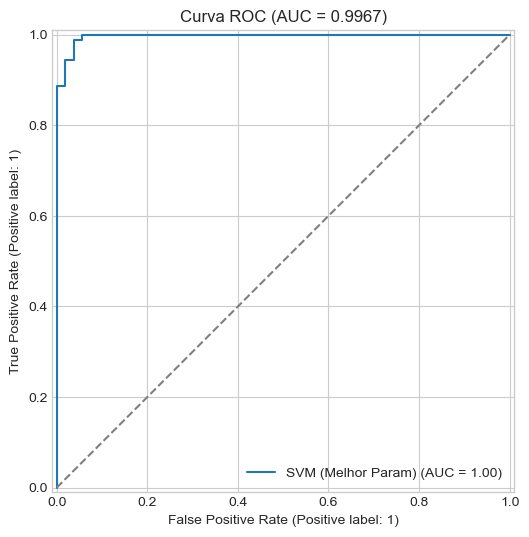

In [ ]:
pipeline.fit(X_train, y_train.values.ravel())

# 2. Obter os scores de decisão
y_scores = pipeline.decision_function(X_test)

# 3. Calcular AUC e Plotar
auc_value = roc_auc_score(y_test, y_scores)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_scores, ax=ax, name='SVM (Melhor Param)')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--') # Linha de base
ax.set_title(f'Curva ROC (AUC = {auc_value:.4f})')
plt.show()

#### Reflexão em texto — Parte 5.1


Resposta: A avaliação de modelos de classificação utilizando apenas a acurácia pode ser enganosa, especialmente em cenários com classes desbalanceadas. A curva ROC (Receiver Operating Characteristic) e a métrica AUC (Area Under the Curve) oferecem uma visão mais robusta sobre a capacidade de um modelo distinguir entre as classe.


### Atividade 5.2 — Importância das features (árvore)
Ajuste uma árvore (com hiperparâmetros que você julgar razoáveis) e utilize o atributo `feature_importances_`. Visualize as importâncias (por exemplo barras horizontais com nomes em `data.feature_names`). Quais atributos aparecem no topo? Isso condiz com o que você viu na matriz de correlação?

> **Enunciado:** `DecisionTreeClassifier.feature_importances_`, `matplotlib` ou `seaborn`.


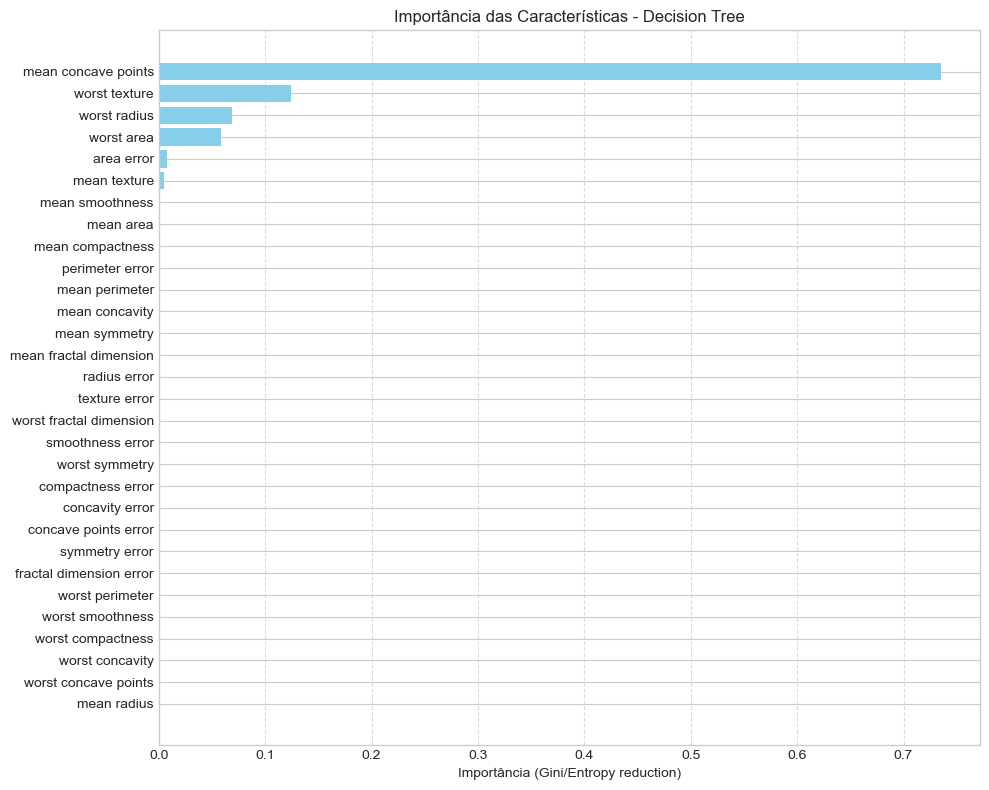

Top 3 características mais importantes:
                Feature  Importancia
7   mean concave points     0.735135
21        worst texture     0.124590
20         worst radius     0.068891


In [ ]:

tree_final = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
tree_final.fit(X_train, y_train.values.ravel())

importancias = tree_final.feature_importances_
features = X.columns # ou data.feature_names

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color='skyblue')
plt.xlabel('Importância (Gini/Entropy reduction)')
plt.title('Importância das Características - Decision Tree')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 3 características mais importantes:")
print(df_importancia.tail(3)[::-1])

### Atividade 5.3 — Comparação de métricas além da acurácia
Calcule no teste: **precisão**, **revocação** e **F1** para a classe positiva (defina qual classe é “positiva” no seu relatório). Use `sklearn.metrics.precision_recall_fscore_support` ou extraia de `classification_report`. Quando uma métrica pode ser mais informativa que a acurácia?

> **Enunciado:** métricas em `sklearn.metrics`.


In [ ]:

y_pred = grid_nb.predict(X_test) # ou o seu melhor pipeline/modelo fitsdo

p, r, f1, s = precision_recall_fscore_support(y_test, y_pred, pos_label=0, average='binary')

print(f"Métricas para a Classe Maligna (0):")
print(f"- Precisão: {p:.4f}")
print(f"- Revocação (Recall): {r:.4f}")
print(f"- F1-Score: {f1:.4f}")

print("\nRelatório Geral:")
print(classification_report(y_test, y_pred, target_names=['Maligno (0)', 'Benigno (1)']))

Métricas para a Classe Maligna (0):
- Precisão: 0.9444
- Revocação (Recall): 0.9444
- F1-Score: 0.9444

Relatório Geral:
              precision    recall  f1-score   support

 Maligno (0)       0.94      0.94      0.94        54
 Benigno (1)       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



### Atividade 5.4 — (Opcional) Curva de aprendizado
Use `sklearn.model_selection.learning_curve` com um pipeline (escalonador + classificador) para ver como a métrica evolui com o tamanho do conjunto de treino. O que sugere sobre viés e variância?

> **Enunciado:** `learning_curve`.


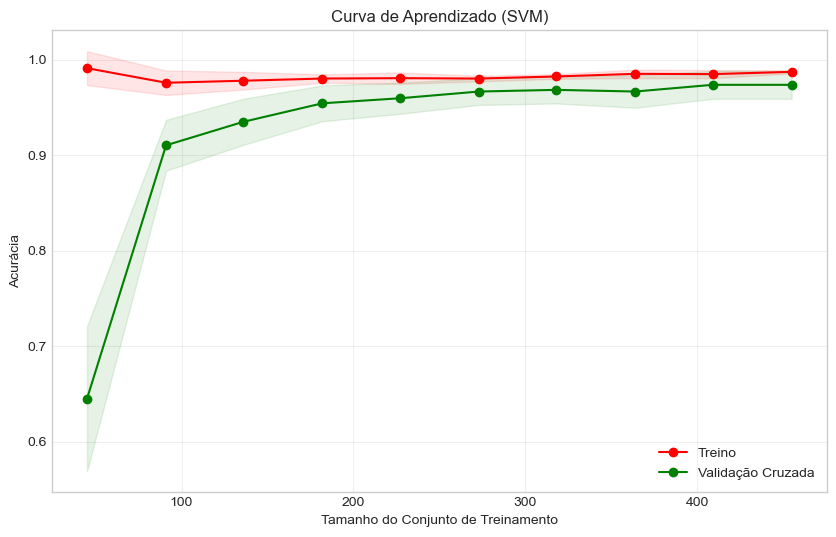

In [ ]:
from sklearn.model_selection import  learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y.values.ravel(), cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Treino")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validação Cruzada")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Curva de Aprendizado (SVM)")
plt.xlabel("Tamanho do Conjunto de Treinamento")
plt.ylabel("Acurácia")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

### Atividade 5.5 — (Opcional) Naive Bayes multinomial
Este dataset é numérico contínuo; o `MultinomialNB` é típico de contagens. Pe### Atividade 5.5 — (Opcional) Naive Bayes multinomial
Este dataset é numérico contínuo; o `MultinomialNB` é típico de contagens. Pesquise na documentação quando usar `MultinomialNB` vs `GaussianNB` e descreva um exemplo de problema para cada um.


#### Reflexão em texto — Parte 5.5
Resposta: MultinomialNB são indicado para dados discretos, especificamente contagens (frequência de eventos) ja GaussianNB são Indicado para dados numéricos contínuos que seguem uma distribuição normal (Gaussiana). 




### Atividade 5.6 — (Opcional) Importância por permutação

A importância baseada em `feature_importances_` na árvore é **específica desse modelo**. Uma alternativa mais geral é medir quanto a métrica piora quando cada atributo é embaralhado aleatoriamente no conjunto de **teste** (ou validação). Use `sklearn.inspection.permutation_importance` com um pipeline já treinado (por exemplo SVM ou árvore) e compare mentalmente com o ranking da Parte 5.2.

> **Enunciado:** `permutation_importance`.


<Figure size 1000x800 with 0 Axes>

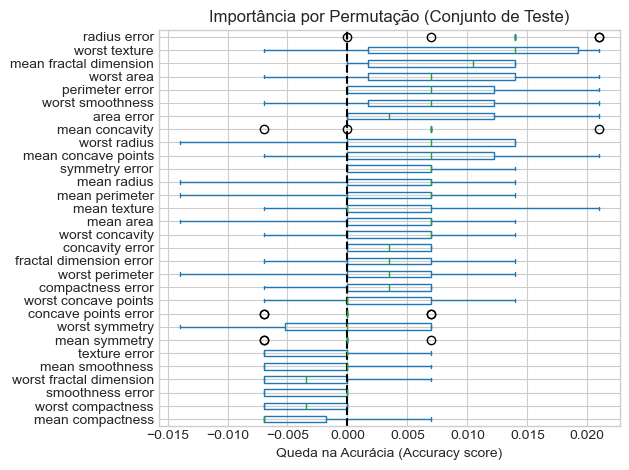

Top 3 features por Permutação:
Index(['radius error', 'worst texture', 'mean fractal dimension'], dtype='object')


<Figure size 1000x800 with 0 Axes>

In [ ]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    pipeline, X_test, y_test.values.ravel(), n_repeats=10, random_state=42, n_jobs=-1
)
sorted_importances_idx = result.importances_mean.argsort()
importancias_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

plt.figure(figsize=(10, 8))
importancias_df.plot.box(vert=False, whis=10)
plt.title("Importância por Permutação (Conjunto de Teste)")
plt.axvline(x=0, color="k", linestyle="--")
plt.xlabel("Queda na Acurácia (Accuracy score)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
print("Top 3 features por Permutação:")
print(importancias_df.columns[-3:][::-1])

---

## Sugestão de auto-check formativo

Perguntas para **você** refletir sobre o que aprendeu — **não** são critérios de nota.

- [ ] Entendi o formato dos dados, as classes e se há desbalanceamento.
- [ ] Implementei treino/teste, escalonamento no treino e três modelos baseline no **meu** código.
- [ ] Explorei hiperparâmetros (árvore, SVM, NB) com validação no **treino** e anotei o que mudou ao variar parâmetros.
- [ ] Consigo explicar a diferença entre a Parte 3 (escolha de hiperparâmetros) e a Parte 4 (CV com pipeline no conjunto completo).
- [ ] Explico por que o `StandardScaler` deve ficar **dentro** do `Pipeline` na validação cruzada.
- [ ] (Opcional) Experimentei uma ou mais seções da Parte 5.

Se **reiniciar o kernel** e executar em ordem, a demonstração e os imports devem rodar; o restante depende do código que você for acrescentando.

**Bom trabalho!**
